In [1]:

import numpy as np
import pandas as pd
import plotly.graph_objects as go

StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 3, Finished, Available, Finished)

In [2]:
# ─────────────────────────────────────────────────────────────
# Paso 1: Cargar dataset anonimizado desde Bronce (Excel local)
# ─────────────────────────────────────────────────────────────


# Ruta válida en notebooks Fabric con kernel Pandas
ruta_excel = "/lakehouse/default/Files/raw/BD_ARANDA_anon.xlsx"

# Cargar el Excel completo
try:
    df = pd.read_excel(ruta_excel)
    print("✅ Dataset cargado correctamente. Número de filas y columnas:", df.shape)
except Exception as e:
    print("❌ Error al cargar el dataset:", e)

# Ver resumen
df.info()



StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 4, Finished, Available, Finished)

✅ Dataset cargado correctamente. Número de filas y columnas: (19863, 114)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19863 entries, 0 to 19862
Columns: 114 entries, Caso to Causa del Incidente
dtypes: datetime64[ns](18), float64(15), int64(8), object(73)
memory usage: 17.3+ MB


In [3]:
# ─────────────────────────────────────────────────────────────
# Paso 2: Inspección general de tipos de datos
# Objetivo: identificar el tipo de dato de cada columna
# ─────────────────────────────────────────────────────────────

# Obtener los tipos de datos por columna
tipos_datos = df.dtypes.reset_index()
tipos_datos.columns = ['Columna', 'Tipo_de_dato']

# Contar cuántas columnas hay por tipo
conteo_tipos = tipos_datos['Tipo_de_dato'].value_counts()

# Mostrar resumen
print("📊 Resumen de tipos de datos encontrados:")
display(conteo_tipos)

# Mostrar tabla con los tipos por columna
print("\n🔍 Tipos de datos por columna:")
display(tipos_datos.sort_values(by='Tipo_de_dato'))


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 5, Finished, Available, Finished)

📊 Resumen de tipos de datos encontrados:


Tipo_de_dato
object            73
datetime64[ns]    18
float64           15
int64              8
Name: count, dtype: int64


🔍 Tipos de datos por columna:


SynapseWidget(Synapse.DataFrame, 21506305-24d6-47cf-ac4b-4a3bf8061643)

In [4]:
# ─────────────────────────────────────────────────────────────
# Paso 2.1: Convertir columnas clave a texto (str) y mostrar
# ─────────────────────────────────────────────────────────────

columnas_id = ['Caso', 'periodo_reg', 'periodo_cierre_sol']

for col in columnas_id:
    if col in df.columns:
        df[col] = df[col].astype(str)
        print(f"🔁 Columna '{col}' convertida a texto (str)")
    else:
        print(f"⚠️ Columna '{col}' no encontrada en el dataset")

# Mostrar tipos actualizados solo para esas columnas
print("\n📋 Tipos actualizados para columnas clave:")
display(df[columnas_id].dtypes)

# Mostrar primeras filas con esas columnas
print("\n🔍 Vista previa de las columnas clave convertidas:")
display(df[columnas_id].head())


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 6, Finished, Available, Finished)

🔁 Columna 'Caso' convertida a texto (str)
🔁 Columna 'periodo_reg' convertida a texto (str)
🔁 Columna 'periodo_cierre_sol' convertida a texto (str)

📋 Tipos actualizados para columnas clave:


Caso                  object
periodo_reg           object
periodo_cierre_sol    object
dtype: object


🔍 Vista previa de las columnas clave convertidas:


SynapseWidget(Synapse.DataFrame, f1a26d62-d89e-48d6-9c12-6a16d6b0c999)

In [5]:
# ─────────────────────────────────────────────────────────────
# Paso 2.2: Normalizar valores numéricos mal interpretados como flotantes
#           (por ejemplo: 20198.0 → "20198")
# ─────────────────────────────────────────────────────────────

def normalizar_periodo(valor):
    try:
        return str(int(float(valor))) if pd.notna(valor) else None
    except:
        return str(valor)  # fallback si ya es string correcto

for col in ['periodo_reg', 'periodo_cierre_sol','Dias_Del_Estado','Tiempo_de_Respuesta']:
    if col in df.columns:
        df[col] = df[col].apply(normalizar_periodo)
        print(f"🔧 Columna '{col}' normalizada sin decimales.")

# Verificamos resultado final
print("\n🧾 Vista previa corregida:")
display(df[['periodo_reg', 'periodo_cierre_sol','Dias_Del_Estado','Tiempo_de_Respuesta']].head())


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 7, Finished, Available, Finished)

🔧 Columna 'periodo_reg' normalizada sin decimales.
🔧 Columna 'periodo_cierre_sol' normalizada sin decimales.
🔧 Columna 'Dias_Del_Estado' normalizada sin decimales.
🔧 Columna 'Tiempo_de_Respuesta' normalizada sin decimales.

🧾 Vista previa corregida:


SynapseWidget(Synapse.DataFrame, 98c5333b-5098-4fb7-97fa-8c11b9b89805)

In [6]:
# ─────────────────────────────────────────────────────────────
# Paso 3: Análisis de valores nulos por columna
# ─────────────────────────────────────────────────────────────

# Total de filas
total_filas = len(df)

# Calcular número y porcentaje de nulos por columna
nulos = df.isnull().sum().reset_index()
nulos.columns = ['Columna', 'Nulos']
nulos['% Nulos'] = (nulos['Nulos'] / total_filas * 100).round(2)

# Filtrar columnas que tengan al menos 1 nulo
nulos_filtrados = nulos[nulos['Nulos'] > 0].sort_values(by='% Nulos', ascending=False)

# Mostrar resumen
print(f"🔍 Se encontraron {nulos_filtrados.shape[0]} columnas con valores nulos.\n")
display(nulos_filtrados)


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 8, Finished, Available, Finished)

🔍 Se encontraron 71 columnas con valores nulos.



SynapseWidget(Synapse.DataFrame, 8a846b5e-3981-4e40-9321-7f86421bff08)

In [7]:
# ─────────────────────────────────────────────────────────────
# Paso 3.1: Mostrar todos los resultados sin truncar
# ─────────────────────────────────────────────────────────────

# Configurar pandas para no truncar filas al mostrar
with pd.option_context('display.max_rows', None):
    display(nulos_filtrados)


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 9, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, 9b6a00d5-4a8e-4812-af98-b8641d591835)

In [8]:
# ─────────────────────────────────────────────────────────────
# Paso 4: Clasificación de columnas con nulos
# ─────────────────────────────────────────────────────────────

# 1. Total de registros
total_filas = len(df)

# 2. Cálculo de nulos por columna
nulos = df.isnull().sum().reset_index()
nulos.columns = ['Columna', 'Nulos']
nulos['% Nulos'] = (nulos['Nulos'] / total_filas * 100).round(2)

# ─────────────────────────────────────────────────────────────
# 1️⃣ Eliminar columnas con 100% nulos
# ─────────────────────────────────────────────────────────────
columnas_nulas_100 = nulos[nulos['% Nulos'] == 100]['Columna'].tolist()

print(f"🗑️ Se eliminarán {len(columnas_nulas_100)} columnas con 100% de nulos:")
for col in columnas_nulas_100:
    print(f"  - {col}")
    
df.drop(columns=columnas_nulas_100, inplace=True)

# ─────────────────────────────────────────────────────────────
# 2️⃣ Marcar columnas a evaluar (80% a 99.99%)
# ─────────────────────────────────────────────────────────────
columnas_a_evaluar = nulos[
    (nulos['% Nulos'] >= 80) & (nulos['% Nulos'] < 100)
]['Columna'].tolist()

print(f"\n🔎 Se marcaron {len(columnas_a_evaluar)} columnas para evaluación futura:")
for col in columnas_a_evaluar:
    print(f"  - {col}")

# ─────────────────────────────────────────────────────────────
# 3️⃣ Marcar columnas con imputación sugerida (10% a <80%)
# ─────────────────────────────────────────────────────────────
columnas_imputables = nulos[
    (nulos['% Nulos'] >= 10) & (nulos['% Nulos'] < 80)
]['Columna'].tolist()

print(f"\n🧩 Se identificaron {len(columnas_imputables)} columnas posibles para imputación:")
for col in columnas_imputables:
    print(f"  - {col}")

# ─────────────────────────────────────────────────────────────
# 4️⃣ Confirmar columnas clave preservadas (menos del 10% nulos)
# ─────────────────────────────────────────────────────────────
columnas_clave_preservadas = nulos[
    (nulos['% Nulos'] < 10) & (nulos['% Nulos'] > 0)
]['Columna'].tolist()

print(f"\n✅ Se preservan {len(columnas_clave_preservadas)} columnas relevantes con pocos nulos:")
for col in columnas_clave_preservadas:
    print(f"  - {col}")


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 10, Finished, Available, Finished)

🗑️ Se eliminarán 6 columnas con 100% de nulos:
  - Fecha_Bloqueo
  - Detallar_Justif.
  - Fecha_Justif.
  - FECHA_FIN_DESARROLLO
  - Recordatorio
  - Fecha_Recordatorio

🔎 Se marcaron 36 columnas para evaluación futura:
  - Sede
  - Etapa
  - Cod. Proyecto
  - Fecha Entrega
  - Duración Estimada
  - Clasificación
  - Prioridad Negocio
  - Prioridad Interna
  - Cl Asociado
  - Motivo Bloqueo
  - Justificado
  - FECHA_INICIO_RELEVA
  - FECHA_FIN_RELEVA
  - FECHA_INICIO_ANALISIS
  - FECHA_FIN_ANALISIS
  - FECHA_INICIO_DESARROLLO
  - FECH_INI_PRUE_USER
  - FECH_FIN_PRUE_USER
  - FECHA_INI_PRODUCCION
  - FECHA_FIN_PRODUCCION
  - Módulo
  - Módulo_Valor
  - Número_OT_Nro1
  - Número_OT_Nro2
  - Número_OT_Nro3
  - Describir Funcionalidad Actual
  - Describir Funcionalidad Esperada
  - Impacto al Negocio
  - Sustento Impacto al Negocio
  - Transacción
  - Describir Pasos Realizados
  - Parámetros de entrada
  - Complejidad
  - TICKET_PADRE_NroTicket
  - Tipo de Solución
  - Causa del Incidente

In [9]:
# ─────────────────────────────────────────────────────────────
# Paso 4.1: Añadir etiqueta de clasificación al resumen de nulos
# ─────────────────────────────────────────────────────────────

# Copiar tabla de nulos y etiquetar
nulos_clasificados = nulos.copy()
nulos_clasificados['Clasificación'] = 'Sin nulos'  # valor por defecto

# Asignar etiquetas según las listas generadas en el paso anterior
nulos_clasificados.loc[nulos_clasificados['Columna'].isin(columnas_nulas_100), 'Clasificación'] = 'Eliminada'
nulos_clasificados.loc[nulos_clasificados['Columna'].isin(columnas_a_evaluar), 'Clasificación'] = 'A Evaluar'
nulos_clasificados.loc[nulos_clasificados['Columna'].isin(columnas_imputables), 'Clasificación'] = 'Imputable'
nulos_clasificados.loc[nulos_clasificados['Columna'].isin(columnas_clave_preservadas), 'Clasificación'] = 'Preservada'

# Mostrar tabla con clasificación completa
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("📋 Tabla completa con clasificación de columnas según % de nulos:")
display(nulos_clasificados.sort_values(by='Clasificación'))

# Confirmar el nuevo estado del DataFrame
print(f"\n📦 Dataset final tras limpieza: {df.shape[0]} filas × {df.shape[1]} columnas")
display(df.head())



StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 11, Finished, Available, Finished)

📋 Tabla completa con clasificación de columnas según % de nulos:


SynapseWidget(Synapse.DataFrame, 7abc36f3-c2da-474d-af1a-727053e0a7ae)


📦 Dataset final tras limpieza: 19863 filas × 108 columnas


SynapseWidget(Synapse.DataFrame, 531e1fbf-907f-4374-96e8-b9a607623c1f)

In [10]:
# ─────────────────────────────────────────────────────────────
# Paso 4.2: Eliminar columnas marcadas como "A Evaluar" (con excepciones)
# ─────────────────────────────────────────────────────────────

# Definir excepciones a conservar
# columnas_excluir = ['Fecha Entrega', 'Tipo de Solución', 'Causa del Incidente']

# Filtrar columnas a eliminar (clasificadas como "A Evaluar", pero que NO están en excepciones)
columnas_a_eliminar_4_2 = nulos_clasificados[
    (nulos_clasificados['Clasificación'] == 'A Evaluar') 
]['Columna'].tolist()

# Eliminar del DataFrame
df.drop(columns=columnas_a_eliminar_4_2, inplace=True)

# Confirmar eliminación
print(f"🧹 Se eliminaron {len(columnas_a_eliminar_4_2)} columnas marcadas como 'A Evaluar', excluyendo las excepciones:")
for col in columnas_a_eliminar_4_2:
    print(f"  - {col}")

# Mostrar forma actualizada del DataFrame
print(f"\n📦 Dataset actualizado → {df.shape[0]} filas × {df.shape[1]} columnas")
display(df.head())


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 12, Finished, Available, Finished)

🧹 Se eliminaron 36 columnas marcadas como 'A Evaluar', excluyendo las excepciones:
  - Sede
  - Etapa
  - Cod. Proyecto
  - Fecha Entrega
  - Duración Estimada
  - Clasificación
  - Prioridad Negocio
  - Prioridad Interna
  - Cl Asociado
  - Motivo Bloqueo
  - Justificado
  - FECHA_INICIO_RELEVA
  - FECHA_FIN_RELEVA
  - FECHA_INICIO_ANALISIS
  - FECHA_FIN_ANALISIS
  - FECHA_INICIO_DESARROLLO
  - FECH_INI_PRUE_USER
  - FECH_FIN_PRUE_USER
  - FECHA_INI_PRODUCCION
  - FECHA_FIN_PRODUCCION
  - Módulo
  - Módulo_Valor
  - Número_OT_Nro1
  - Número_OT_Nro2
  - Número_OT_Nro3
  - Describir Funcionalidad Actual
  - Describir Funcionalidad Esperada
  - Impacto al Negocio
  - Sustento Impacto al Negocio
  - Transacción
  - Describir Pasos Realizados
  - Parámetros de entrada
  - Complejidad
  - TICKET_PADRE_NroTicket
  - Tipo de Solución
  - Causa del Incidente

📦 Dataset actualizado → 19863 filas × 72 columnas


SynapseWidget(Synapse.DataFrame, 153133a7-b4ba-440b-bea8-38acb3a9a77e)

In [11]:
# ─────────────────────────────────────────────────────────────
# Paso 4.3: Eliminar columnas marcadas como "Imputables" (con excepciones)
# ─────────────────────────────────────────────────────────────

# Definir excepciones a conservar
# columnas_excluir_4_3 = ['Jefe', 'Analista Responsable']

# Filtrar columnas a eliminar (clasificadas como "Imputable" pero no excepciones)
columnas_a_eliminar_4_3 = nulos_clasificados[
    (nulos_clasificados['Clasificación'] == 'Imputable')
]['Columna'].tolist()

# Eliminar del DataFrame
df.drop(columns=columnas_a_eliminar_4_3, inplace=True)

# Confirmar eliminación
print(f"🧹 Se eliminaron {len(columnas_a_eliminar_4_3)} columnas marcadas como 'Imputable', excluyendo excepciones:")
for col in columnas_a_eliminar_4_3:
    print(f"  - {col}")

# Mostrar forma final del DataFrame
print(f"\n📦 Dataset actualizado → {df.shape[0]} filas × {df.shape[1]} columnas")
display(df.head())


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 13, Finished, Available, Finished)

🧹 Se eliminaron 11 columnas marcadas como 'Imputable', excluyendo excepciones:
  - Jefe
  - Oficina
  - Analista Responsable
  - Última Nota
  - Autor Últ. Nota
  - Fecha Últ. Nota
  - Categoría N4
  - Notas_Dias
  - Nota_Plazo
  - Id_Rango_Notas_Dias
  - Rango_Notas_Dias

📦 Dataset actualizado → 19863 filas × 61 columnas


SynapseWidget(Synapse.DataFrame, 1f095972-e1a1-4e85-8cc4-e937e924c3f9)

In [12]:
# ─────────────────────────────────────────────────────────────
# Paso 4.4 (ajustado): Eliminar fechas inválidas según reglas específicas
# ─────────────────────────────────────────────────────────────

# Contar registros antes de limpieza
filas_antes = df.shape[0]

# Asegurar que todas las fechas necesarias estén en formato datetime
df['Fecha de Registro'] = pd.to_datetime(df['Fecha de Registro'], errors='coerce')
df['Fecha Solución'] = pd.to_datetime(df['Fecha Solución'], errors='coerce')
df['Fecha Cierre'] = pd.to_datetime(df['Fecha Cierre'], errors='coerce')
df['Fecha último Estado'] = pd.to_datetime(df['Fecha último Estado'], errors='coerce')

# Condición 1: Fecha Solución no es anterior a Fecha de Registro (se permiten valores nulos)
condicion_1 = df['Fecha Solución'].isna() | (df['Fecha Solución'] >= df['Fecha de Registro'])

# Condición 2: Fecha último Estado no debe ser posterior a Fecha Cierre (se permiten valores nulos)
condicion_2 = df['Fecha último Estado'].isna() | df['Fecha Cierre'].isna() | (df['Fecha último Estado'] <= df['Fecha Cierre'])

# Aplicar condiciones
df = df[condicion_1 & condicion_2].copy()

# Contar registros después de limpieza
filas_despues = df.shape[0]

# Mostrar resultados
print(f"🧹 Filas eliminadas por fechas inválidas: {filas_antes - filas_despues}")
print(f"📦 Dataset actualizado → {df.shape[0]} filas × {df.shape[1]} columnas")


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 14, Finished, Available, Finished)

🧹 Filas eliminadas por fechas inválidas: 15
📦 Dataset actualizado → 19848 filas × 61 columnas


In [13]:
# ─────────────────────────────────────────────────────────────
# Paso 4.5: Reemplazar NaN, NaT, inf e -inf por None (equivalente a NULL)
# ─────────────────────────────────────────────────────────────


# Reemplazar Infinitos por NaN (precaución para columnas numéricas)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Reemplazar todos los NaN/NaT por None (compatible con Spark/SQL)
df = df.where(pd.notnull(df), None)

# Confirmar limpieza
print("🔁 Todos los NaN, NaT, inf y -inf fueron convertidos a None.")
df.head()


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 15, Finished, Available, Finished)

🔁 Todos los NaN, NaT, inf y -inf fueron convertidos a None.


,Caso,Tipo de Caso,Tipo de Registro,Fecha de Registro,Autor,Grupo Resolutor,Especialista,Cliente,Cargo,Dirección orig,Sub Gerencia orig,Servicio,SLA Nombre,SLA Minutos,Tiempo_transcurrido,Cumplimiento SLQ,Tiempo_de_Respuesta,Criticidad,Categoria,Categoría N1,Categoría N2,Categoría N3,Estado Específico,Razón,Fecha Solución,Fecha Cierre,Días pendientes,Rango Días,Asunto,Descripción,Comentario Solución,Ticket Padre,Fecha último Estado,Bloqueado,Cargo 2,Dirección,Sub Gerencia,Dias,Backlog,Fecha Cierre Sol,periodo_reg,periodo_cierre_sol,Cantidad cerrado,Aplicación,Update,ID,etiqueta1,etiqueta2,Sub Tipo,Torre,Estado General,En Curso,Fase,Fecha_Entrega_Esperada,ANS,Dias_Del_Estado,Rango_Dias_Del_Estado,Rango_Sem_Del_Estado,Categoria_Accion,Sub_Tipo_Grupo,Email_Cliente
0,185019136,Requerimiento,CORREO,2019-08-03,Persona_0001,PROV-AYESA - Soporte SAP,Persona_0005,Persona_0295,Analista SAP,DIRECCIÓN DE ABASTECIMIENTO Y SERVICIOS,SUBGERENCIA DE PROYECTO SAP S4 HANA,Servicio de Aplicaciones,M,5040,0,Cumple,0,MUY ALTA,APLICACIONES.SAP.SAP - solicitud de acceso,APLICACIONES,SAP,SAP - solicitud de acceso,CERRADO,Cerrado Automatico,2019-12-19,2019-12-23 12:01:59,999,Más de 60 días,Accesos SAP,"Extender fecha fin de_x000D_\nvalidez hasta el 31.12.2019 a los usuarios E_AYESA06, E_AYESA07,_x000D_\nE_AYESA08, en el sistema QAS.Envía correo: John Marín Hilary (Ayesa)","Estimado_x000D_\nJohn,_x000D_\n _x000D_\nPara_x000D_\ncomentarte que se procedió en extender fecha fin de validez hasta el 31.12.2019_x000D_\na los usuarios E_AYESA06, E_AYESA07, E_AYESA08, en el sistema QAS._x000D_\n _x000D_\nIngresar_x000D_\ncon sus mismas claves.",Ticket Padre,2019-12-23,NO,ANALISTA SAP,DIRECCIÓN DE ABASTECIMIENTO Y SERVICIOS,PROYECTO SAP S4 HANA,138,Más 30 días,2019-12-19,20198,201912,1,SAP - SOLICITUD DE ACCESO,2025-01-27 10:24:00,3683,Registrados,Solucionados,Accesos,SAP,CERRADO,CERRADO,06. Finalizado,2019-08-13 19:00:00,M,857,06. De 36 a más Días,04 Semanas a más,Publicar,Otros,persona_0295@emailanon.com
1,185019141,Requerimiento,CORREO,2019-08-03,Persona_0001,PROV - Aplicaciones,Persona_0005,Persona_0169,Subgerente De Mantenimiento,DIRECCIÓN DE OPERACIONES,Subgerencia de Mantenimiento,Servicio de Aplicaciones,M,5040,0,Cumple,0,MUY ALTA,APLICACIONES.SAP.SAP - solicitud de acceso,APLICACIONES,SAP,SAP - solicitud de acceso,CERRADO,Cerrado Automatico,2019-08-08,2019-08-12 12:01:35,999,Más de 60 días,Acceso SAP,Acceso a Transacción SAP: ME22N.Motivo: Para liberación de Pedidos_x000D_\nCuenta: Rcotacallapa,"Estimado Henry,_x000D_\nTu apoyo en ayudar a Rommel para temas de liberaciones._x000D_\n _x000D_\nSaludos_x000D_\n",Ticket Padre,2019-08-12,NO,SUBGERENTE DE MANTENIMIENTO,DIRECCIÓN DE OPERACIONES,MANTENIMIENTO,6,05 a 10 días,2019-08-08,20198,20198,1,SAP - SOLICITUD DE ACCESO,2025-01-27 10:24:00,3684,Registrados,Solucionados,Accesos,APLICACIONES,CERRADO,CERRADO,06. Finalizado,2019-08-13 19:00:00,M,990,06. De 36 a más Días,04 Semanas a más,Publicar,Otros,persona_0169@emailanon.com
2,185019148,Requerimiento,CORREO,2019-08-03,Persona_0001,PROV-AYESA - Soporte SAP,Persona_0005,Persona_0397,SUBGERENTE DE FINANZAS,DIRECCIÓN DE FINANZAS,SUBGERENCIA DE FINANZAS,Servicio de Aplicaciones,M,5040,0,Cumple,0,MUY ALTA,APLICACIONES.SAP.SAP - solicitud de acceso,APLICACIONES,SAP,SAP - solicitud de acceso,CERRADO,Cerrado Automatico,2019-12-19,2019-12-23 12:01:59,999,Más de 60 días,Acceso SAP,"Acceso a la transacción KAH1 - Crear grupo clases coste, KAH2 - Modificar grupo clases coste, KAH3 - Visualizar grupo clases coste, en el sistema SAP (100).Usuario SAP: AROCCA","Buenos Tardes, Victor._x000D_\n _x000D_\nEl presente es para informar que se habilito al_x000D_\nusuario SAP AROCCA, acceso a la transacción KAH1 - Crear grupo clases_x000D_\ncoste, KAH2 - Modificar grupo clases coste, KAH3 - Visualizar grupo clases_x000D_\ncoste, en el sistema SAP (100)._x000D_\n _x000D_\nRealizar pruebas de ingreso a la transacción_x000D_\nsolicitada y en lo posible validar la funcionalidad que se

In [14]:
# ─────────────────────────────────────────────────────────────
# Paso 5: Análisis de cardinalidad (valores únicos por columna)
# ─────────────────────────────────────────────────────────────

# Calcular número de valores únicos por columna
cardinalidad = df.nunique().reset_index()
cardinalidad.columns = ['Columna', 'Valores_Unicos']

# Clasificar por rango de cardinalidad
bins = [-1, 1, 10, 50, 100, 500, 1000, df.shape[0]]
labels = ['Constante', 'Baja', 'Media', 'Alta', 'Muy Alta', 'Elevada', 'Única']

cardinalidad['Clasificación'] = pd.cut(
    cardinalidad['Valores_Unicos'],
    bins=bins,
    labels=labels
)

# Ordenar por número de valores únicos
cardinalidad_ordenada = cardinalidad.sort_values(by='Valores_Unicos', ascending=True)

# ─────────────────────────────────────────────────────────────
# Resumen estadístico por clasificación
# ─────────────────────────────────────────────────────────────

# Calcular resumen por tipo de clasificación
resumen_cardinalidad = (cardinalidad
                       .groupby('Clasificación', observed=True)
                       .agg(
                           Conteo_Columnas=('Columna', 'count'),
                           Min_Unicos=('Valores_Unicos', 'min'),
                           Max_Unicos=('Valores_Unicos', 'max'),
                           Promedio_Unicos=('Valores_Unicos', 'mean')
                       )
                       .reset_index())

# Formatear valores numéricos
resumen_cardinalidad['Promedio_Unicos'] = resumen_cardinalidad['Promedio_Unicos'].round(1)

# Mostrar resumen
print("\n📊 RESUMEN ESTADÍSTICO DE CARDINALIDAD:")
print("(Clasificación basada en valores únicos por columna)")
display(resumen_cardinalidad)

# ─────────────────────────────────────────────────────────────
# Detalle completo de cardinalidad
# ─────────────────────────────────────────────────────────────

print(f"\n🔍 DETALLE COMPLETO DE CARDINALIDAD ({df.shape[1]} columnas):")
with pd.option_context('display.max_rows', None):
    display(cardinalidad_ordenada)


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 16, Finished, Available, Finished)


📊 RESUMEN ESTADÍSTICO DE CARDINALIDAD:
(Clasificación basada en valores únicos por columna)


SynapseWidget(Synapse.DataFrame, e881a0bb-bed6-4d66-af06-da7339a0a321)


🔍 DETALLE COMPLETO DE CARDINALIDAD (61 columnas):


SynapseWidget(Synapse.DataFrame, abc66fa7-cd86-4fd2-abba-68d821305d5f)

In [15]:
# ─────────────────────────────────────────────────────────────
# Paso 5.1: Eliminar columnas constantes y generar resumen de acciones
# ─────────────────────────────────────────────────────────────

# Detectar columnas con 1 solo valor
columnas_constantes = cardinalidad[cardinalidad['Clasificación'] == 'Constante']['Columna'].tolist()

# Eliminar del DataFrame
df.drop(columns=columnas_constantes, inplace=True)

# Crear columna "Acción" en el resumen
cardinalidad['Acción'] = 'Preservada'
cardinalidad.loc[cardinalidad['Columna'].isin(columnas_constantes), 'Acción'] = 'Eliminada (constante)'

# Para columnas únicas (ID, códigos, etc.) marcar como trazabilidad
columnas_unicas = cardinalidad[cardinalidad['Clasificación'] == 'Única']['Columna'].tolist()
cardinalidad.loc[cardinalidad['Columna'].isin(columnas_unicas), 'Acción'] = 'Preservada (trazabilidad)'

# ─────────────────────────────────────────────────────────────
# Generar resumen tabular como en la imagen
# ─────────────────────────────────────────────────────────────

# Crear DataFrame de resumen
resumen_acciones = (cardinalidad
                   .groupby(['Clasificación', 'Acción'])
                   .size()
                   .reset_index(name='Conteo_Columnas'))

# Pivotear para mejor presentación
resumen_tabular = resumen_acciones.pivot(
    index='Clasificación',
    columns='Acción',
    values='Conteo_Columnas'
).fillna(0).astype(int)

# Ordenar según categorías de cardinalidad
orden_categorias = ['Constante', 'Baja', 'Media', 'Alta', 'Muy Alta', 'Elevada', 'Única']
resumen_tabular = resumen_tabular.reindex(orden_categorias)

# Renombrar columnas para mejor presentación
resumen_tabular.columns = [col.replace('Preservada', 'Columnas Preservadas')
                          .replace('Eliminada', 'Columnas Eliminadas')
                          for col in resumen_tabular.columns]

# Mostrar resumen
print("📋 RESUMEN DE ACCIONES POR CARDINALIDAD:")
display(resumen_tabular)

# ─────────────────────────────────────────────────────────────
# Mostrar detalles completos
# ─────────────────────────────────────────────────────────────

print("\n🔍 DETALLE COMPLETO DE CARDINALIDAD Y ACCIONES:")
with pd.option_context('display.max_rows', None):
    display(cardinalidad.sort_values(by='Valores_Unicos'))

# Mostrar forma del DataFrame resultante
print(f"\n📦 Dataset actualizado → {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"✅ Columnas eliminadas: {len(columnas_constantes)} constantes")
display(df.head())


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 17, Finished, Available, Finished)

📋 RESUMEN DE ACCIONES POR CARDINALIDAD:


SynapseWidget(Synapse.DataFrame, 8d68576a-b203-4b75-a3bb-1f3046276f28)


🔍 DETALLE COMPLETO DE CARDINALIDAD Y ACCIONES:


SynapseWidget(Synapse.DataFrame, a9dc0e4b-f2ee-4198-9ecd-12ecc055c516)


📦 Dataset actualizado → 19848 filas × 57 columnas
✅ Columnas eliminadas: 4 constantes


SynapseWidget(Synapse.DataFrame, 0a2470fa-87da-49a0-bffb-02b9d61f1d57)

In [16]:
# ─────────────────────────────────────────────────────────────
# Paso 5.2: Crear variable temporal 'tiempo_resolucion_dias'
# ─────────────────────────────────────────────────────────────

# Verificar existencia de columnas
if 'Fecha de Registro' in df.columns and 'Fecha Solución' in df.columns:
    
    # Asegurar que ambas columnas estén como datetime
    df['Fecha de Registro'] = pd.to_datetime(df['Fecha de Registro'], errors='coerce')
    df['Fecha Solución'] = pd.to_datetime(df['Fecha Solución'], errors='coerce')
    
    # Calcular la diferencia en días (solo si ambas fechas son válidas)
    df['tiempo_resolucion_dias'] = (df['Fecha Solución'] - df['Fecha de Registro']).dt.days
    
    # Validar duración lógica
    df.loc[df['tiempo_resolucion_dias'] < 0, 'tiempo_resolucion_dias'] = None
    
    print("🕒 Columna 'tiempo_resolucion_dias' creada exitosamente.")

    # Normalizar valores numéricos mal interpretados como flotantes
    #           (por ejemplo: 20198.0 → "20198")
    for col in ['tiempo_resolucion_dias']:
        if col in df.columns:
            df[col] = df[col].apply(normalizar_periodo)
            print(f"🔧 Columna '{col}' normalizada sin decimales.")

    # Verificamos resultado final
    print("\n🧾 Vista previa corregida:")
    display(df[['periodo_reg', 'periodo_cierre_sol','Dias_Del_Estado']].head())



else:
    print("❌ No se encontraron ambas columnas necesarias para calcular la duración.")

# Ver muestra de resultados
display(df[['Fecha de Registro', 'Fecha Solución', 'tiempo_resolucion_dias']].head())


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 18, Finished, Available, Finished)

🕒 Columna 'tiempo_resolucion_dias' creada exitosamente.
🔧 Columna 'tiempo_resolucion_dias' normalizada sin decimales.

🧾 Vista previa corregida:


SynapseWidget(Synapse.DataFrame, 4ea4af2d-54a4-4c04-abfa-23c0a30d0ee4)

SynapseWidget(Synapse.DataFrame, 50d7a1e3-94ce-4c75-acf1-d2a5492279f9)

In [17]:
# ─────────────────────────────────────────────────────────────
# 5.2.1. Conversión de variables temporales a tipo entero
# ─────────────────────────────────────────────────────────────

# Lista de columnas a convertir
columnas_a_convertir = ['tiempo_resolucion_dias', 'Dias_Del_Estado','Tiempo_de_Respuesta']

for col in columnas_a_convertir:
    if col in df.columns:
        # Verificar tipo actual
        print(f"📌 Tipo actual de '{col}': {df[col].dtype}")
        
        # Reemplazar NaN por -1 para permitir conversión
        df[col] = df[col].fillna(-1)
        
        # Convertir a entero
        try:
            df[col] = df[col].astype(int)
            print(f"✅ '{col}' convertido exitosamente a entero.")
        except Exception as e:
            print(f"❌ Error al convertir '{col}':", e)
    else:
        print(f"⚠️ Columna '{col}' no encontrada en el DataFrame.")

# Verificar resultado final
display(df[columnas_a_convertir].sample(5))


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 19, Finished, Available, Finished)

📌 Tipo actual de 'tiempo_resolucion_dias': object
✅ 'tiempo_resolucion_dias' convertido exitosamente a entero.
📌 Tipo actual de 'Dias_Del_Estado': object
✅ 'Dias_Del_Estado' convertido exitosamente a entero.
📌 Tipo actual de 'Tiempo_de_Respuesta': object
✅ 'Tiempo_de_Respuesta' convertido exitosamente a entero.


SynapseWidget(Synapse.DataFrame, 15b1bb12-3c95-46c3-b439-0f239e321205)

In [18]:
# ─────────────────────────────────────────────────────────────
# Paso 6 - Análisis de distribución, correlaciones y valores atípicos
# ─────────────────────────────────────────────────────────────

StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 20, Finished, Available, Finished)

StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 21, Finished, Available, Finished)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_ol

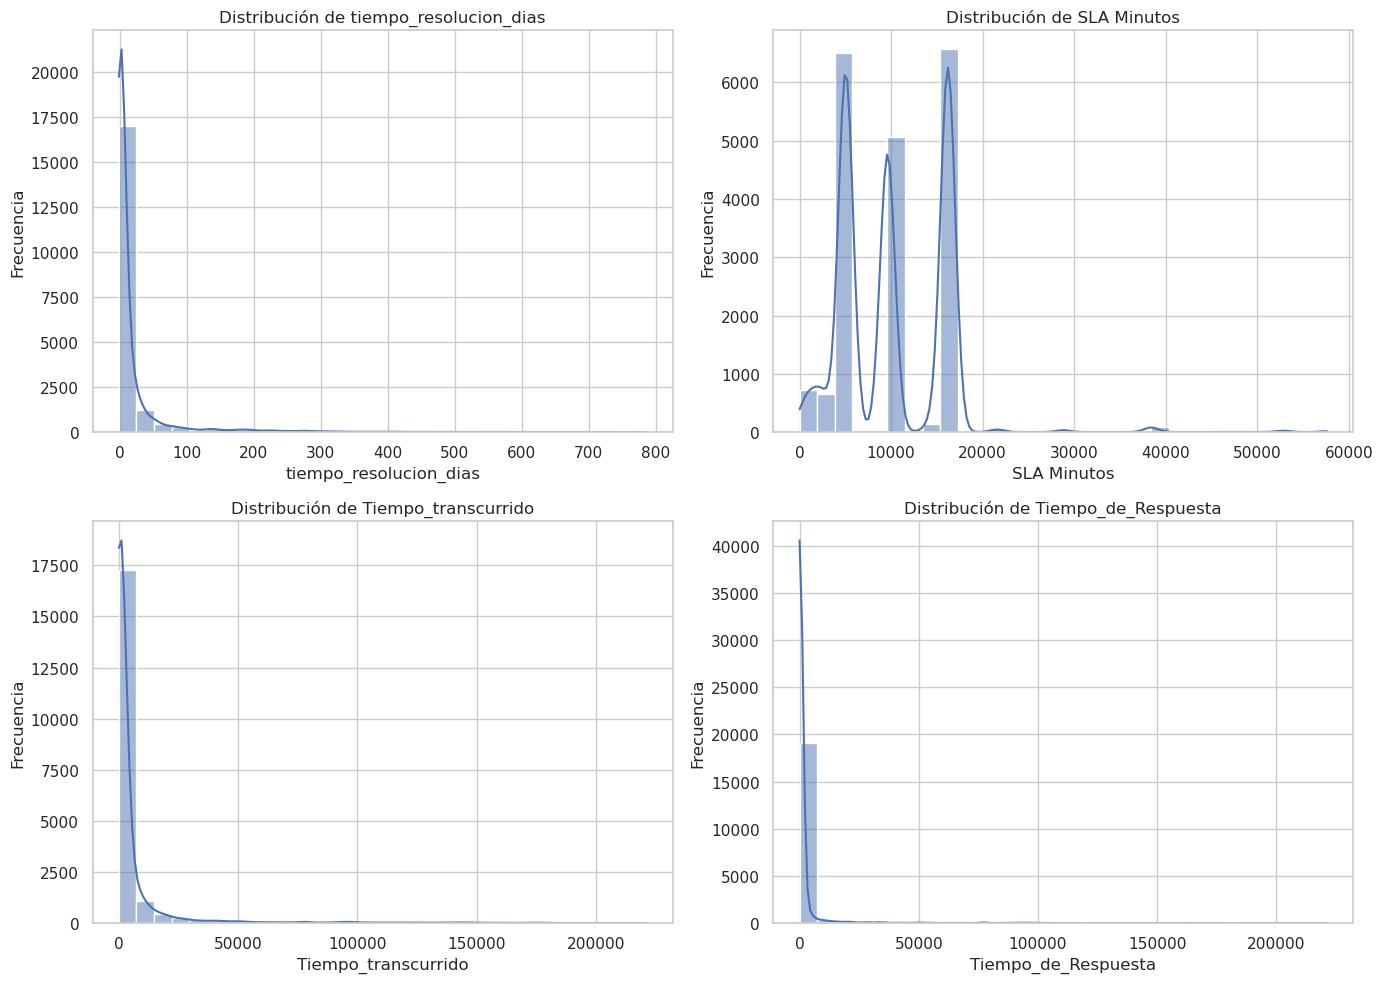

In [19]:
# ─────────────────────────────────────────────────────────────
# Paso 6.1: Histogramas de variables numéricas relevantes
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

variables_numericas = [
    'tiempo_resolucion_dias',
    'SLA Minutos',
    'Tiempo_transcurrido',
    'Tiempo_de_Respuesta'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    if var in df.columns:
        sns.histplot(df[var].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribución de {var}')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


In [20]:
# ─────────────────────────────────────────────────────────────
# Paso 6.2: Distribución de variables categóricas relevantes
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética general
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Variables categóricas clave para el entorno de soporte técnico
variables_categoricas = [
    'Tipo de Caso',
    'Especialista',
    'Grupo Resolutor',
    'Especialista',
    'Cliente',
    'Cargo',
    'Dirección orig',
    'Sub Gerencia orig',
    'Servicio',
    'SLA Nombre',
    'Criticidad',
    'Categoria',
    'Categoría N1',
    'Categoría N2',
    'Categoría N3',
    'Analista Responsable',
    'Torre',
    'Sub_Tipo_Grupo'

]




StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 22, Finished, Available, Finished)

StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 23, Finished, Available, Finished)

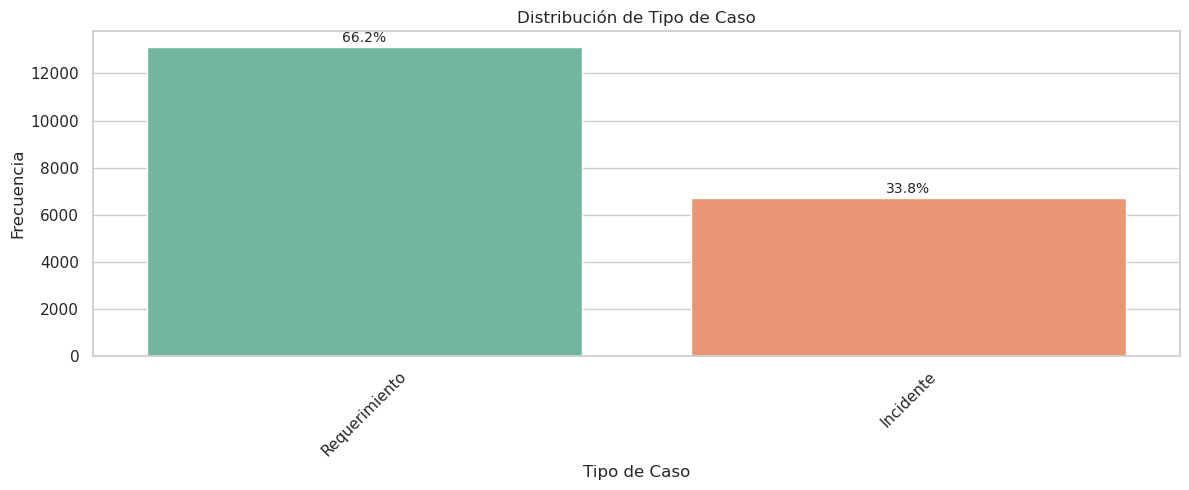

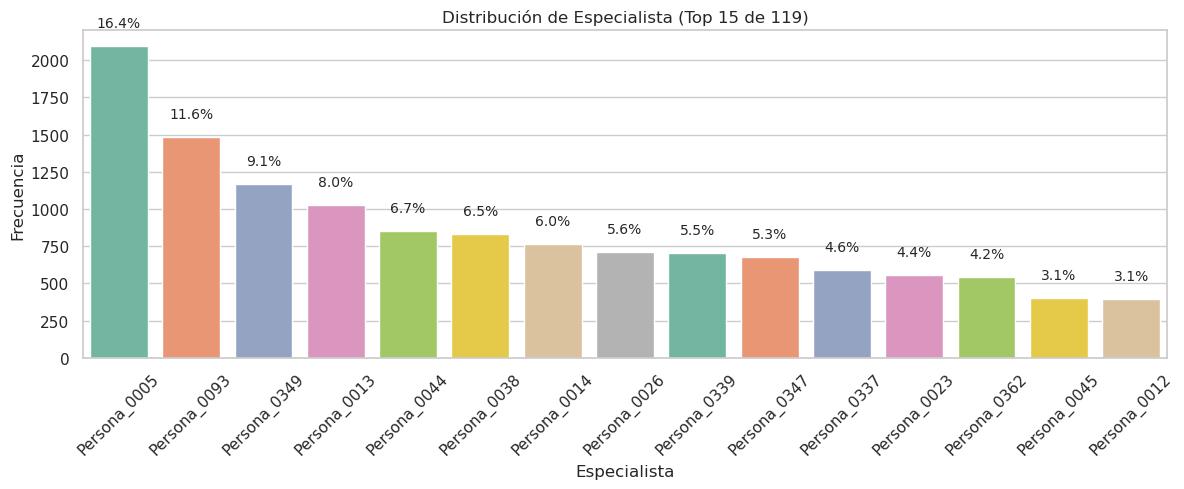

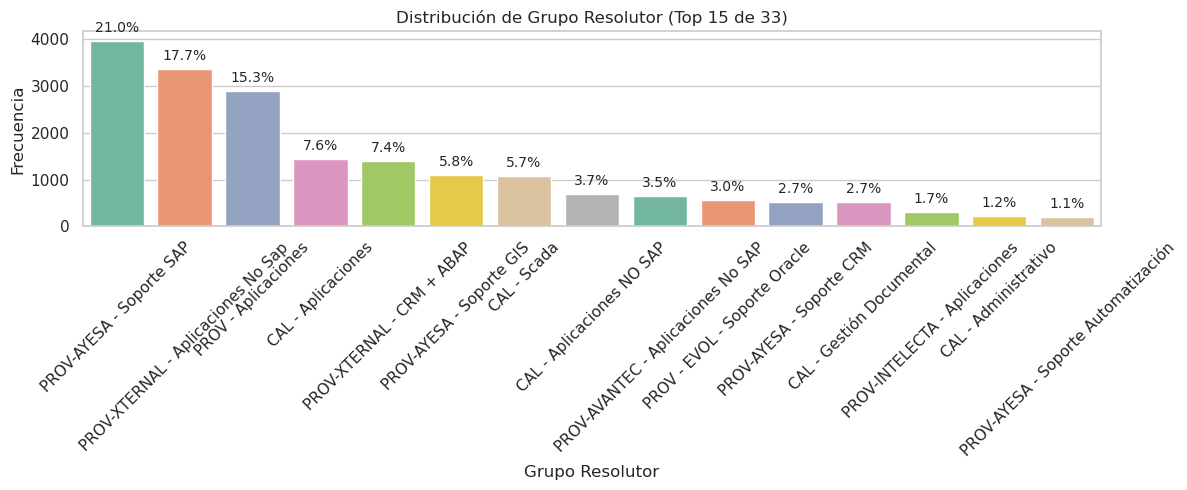

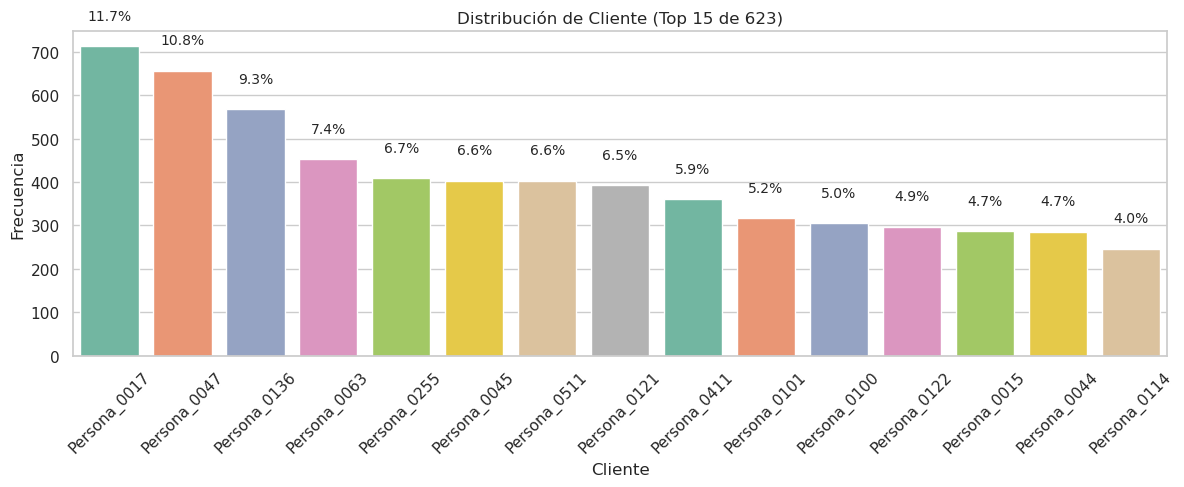

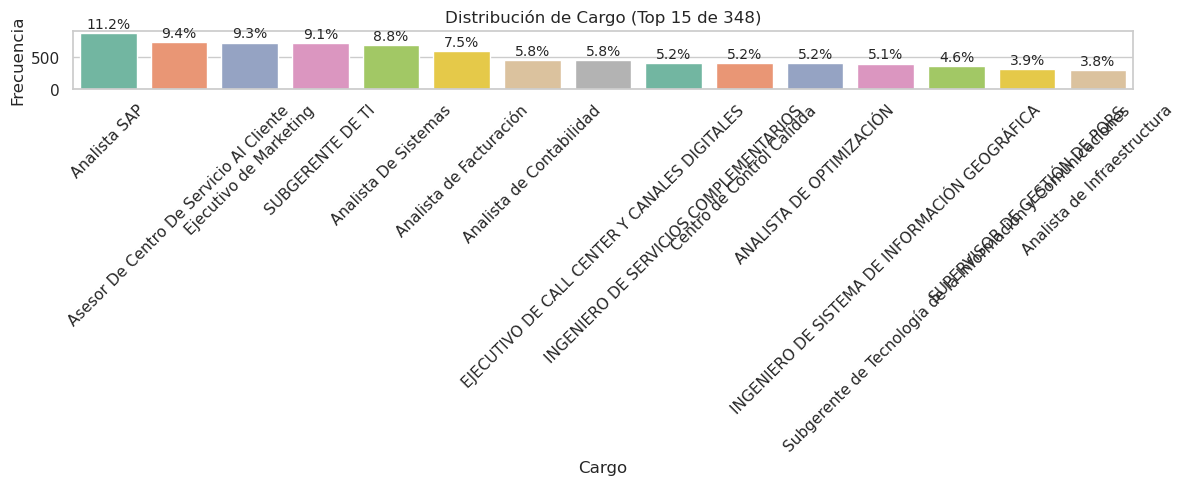

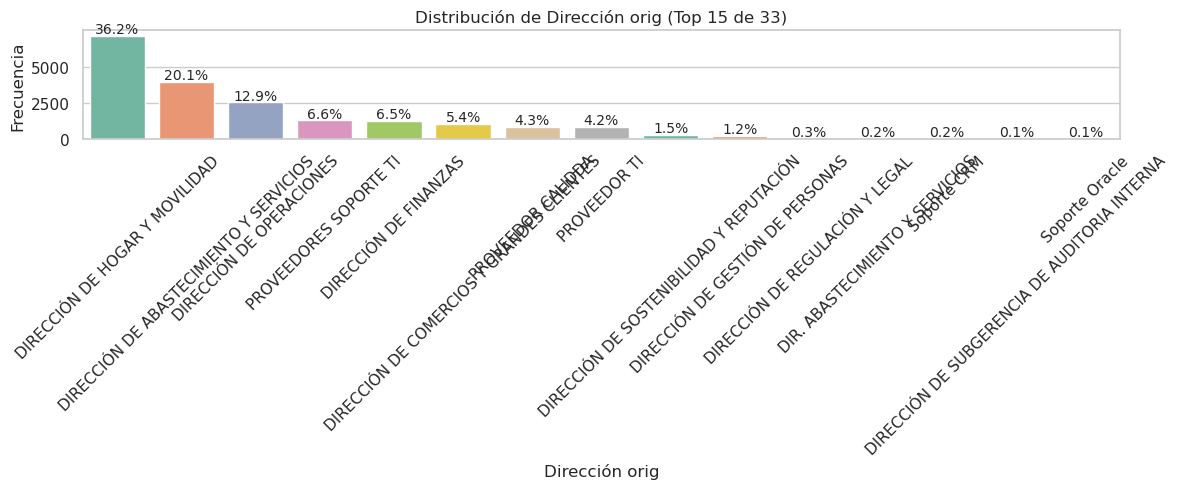

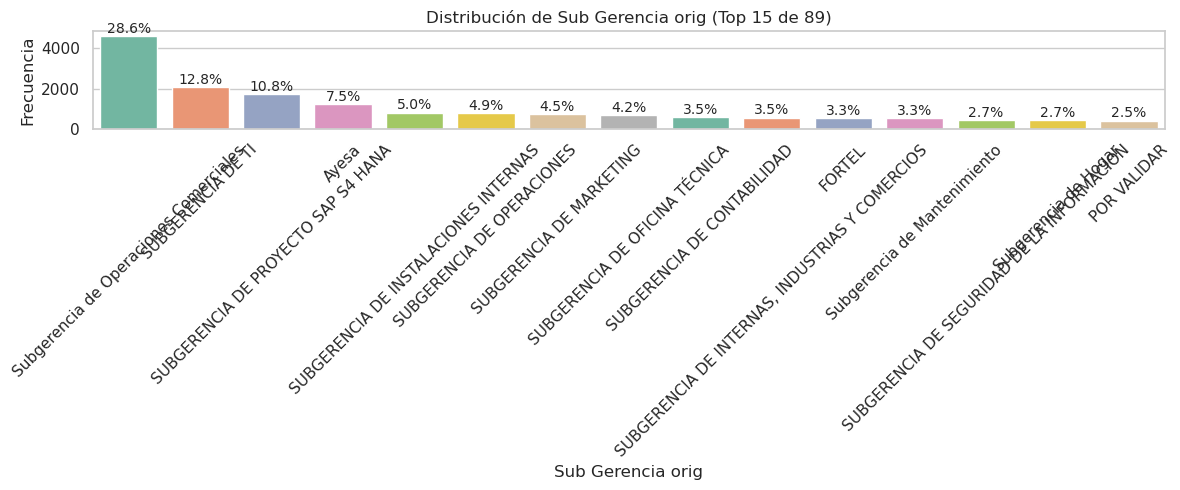

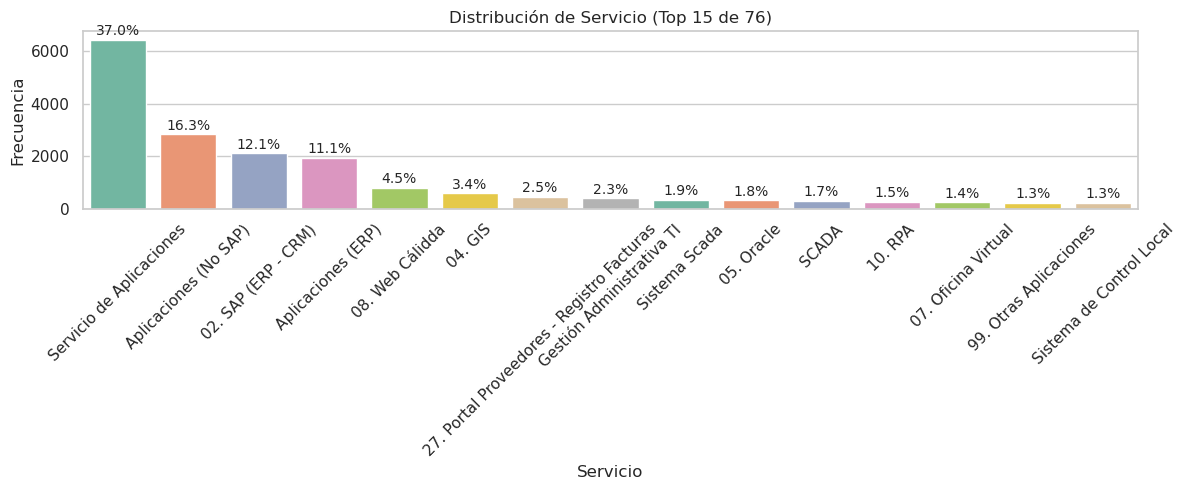

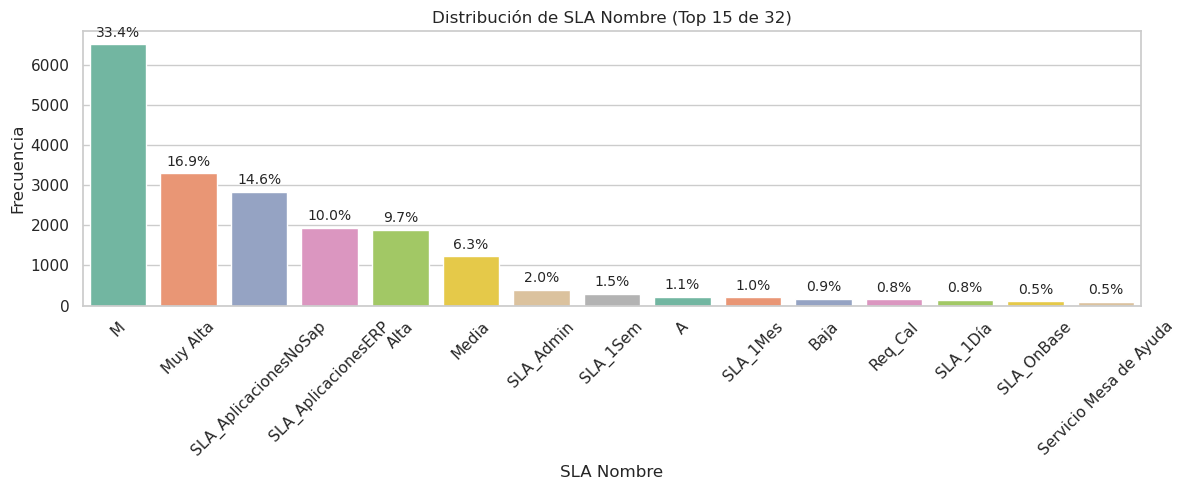

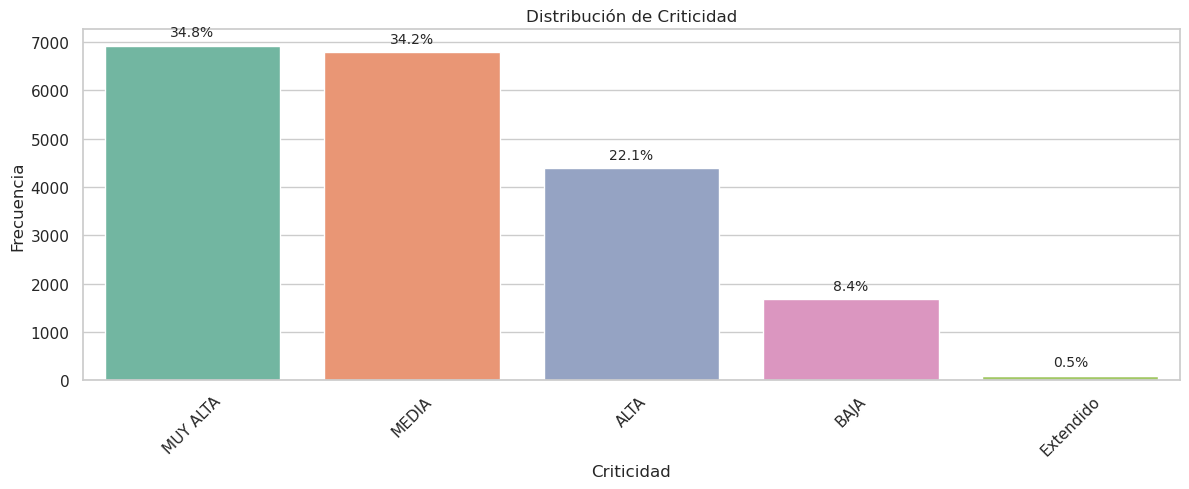

/tmp/ipykernel_6202/4039826448.py:84: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


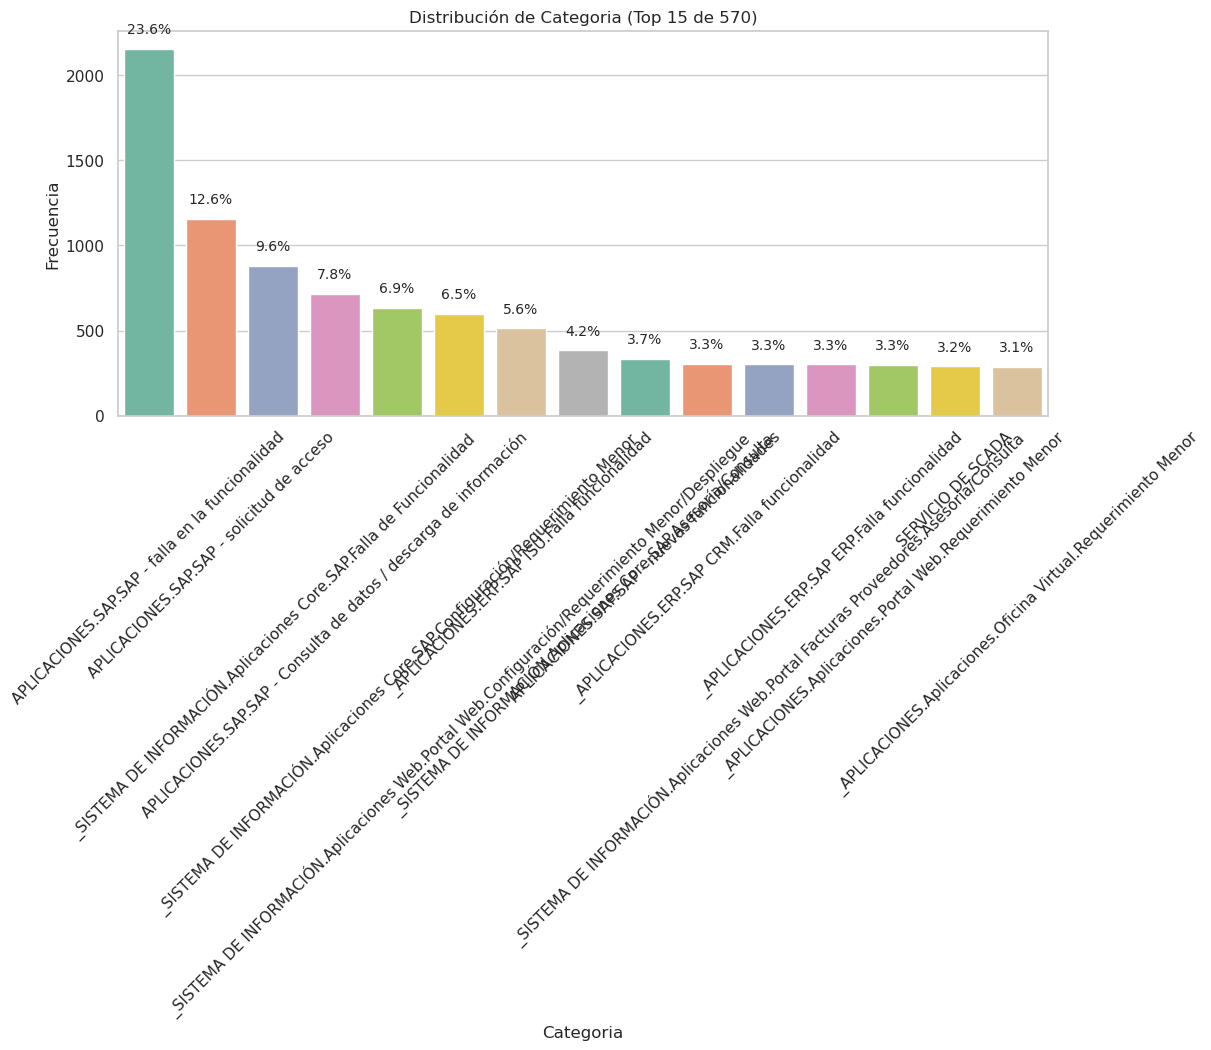

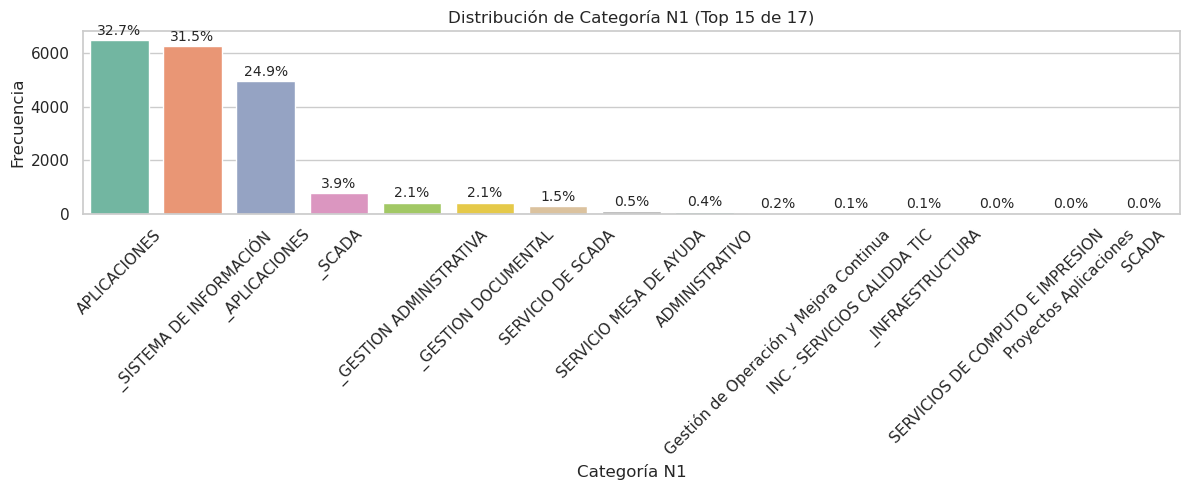

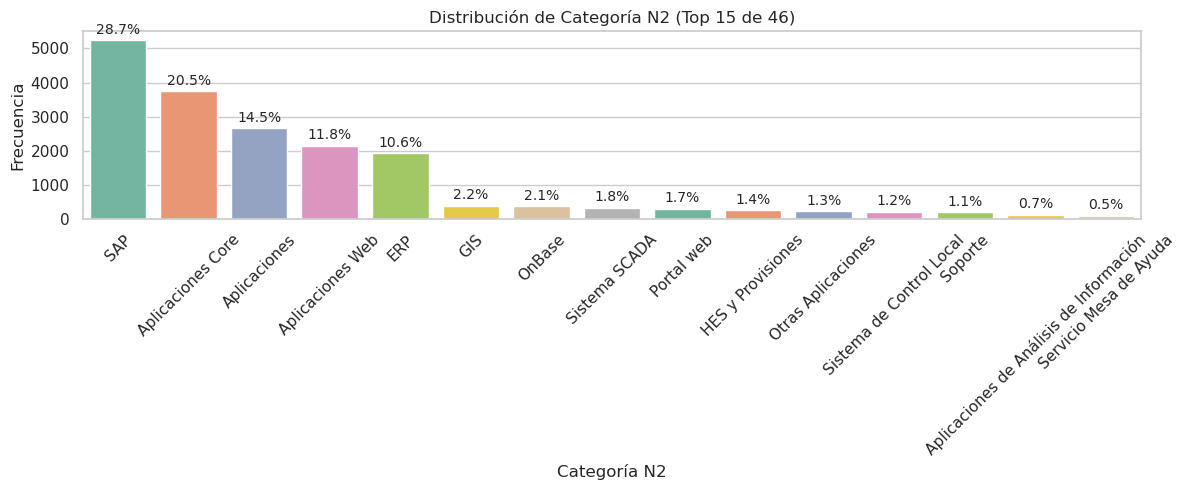

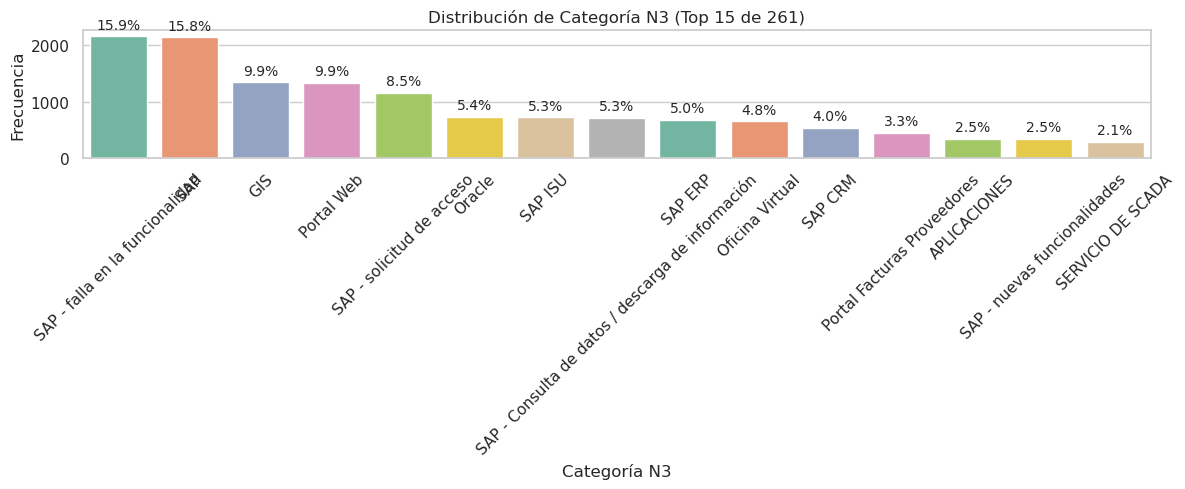

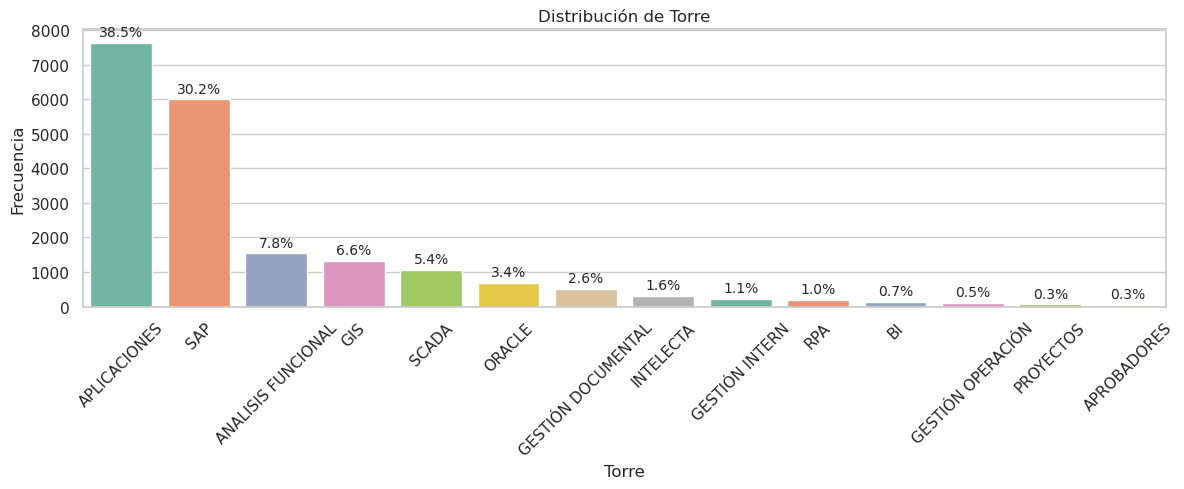

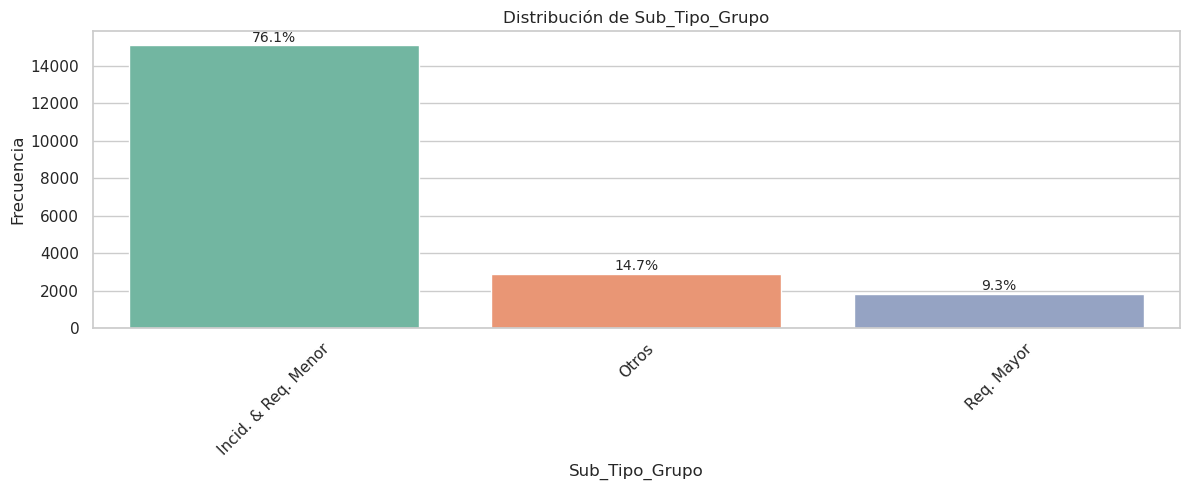

════════════════════════════════════════════════════════════════════════════════
INFORME RESUMIDO DE VARIABLES CATEGÓRICAS
════════════════════════════════════════════════════════════════════════════════


SynapseWidget(Synapse.DataFrame, 17fc8728-e710-47b3-b594-b5cd78ad4a6d)


════════════════════════════════════════════════════════════════════════════════
RECOMENDACIONES PARA PREPARACIÓN DE DATOS
════════════════════════════════════════════════════════════════════════════════

Variable: Especialista
- Cardinalidad muy alta (119 categorías). Considerar agrupar categorías raras o usar técnicas como target encoding.
- Tiene 89 categorías con menos del 1% de frecuencia. Considerar agruparlas en 'OTROS'.

Variable: Grupo Resolutor
- Cardinalidad alta (33 categorías). Considerar one-hot encoding para categorías principales y agrupar el resto.
- Tiene 18 categorías con menos del 1% de frecuencia. Considerar agruparlas en 'OTROS'.

Variable: Cliente
- Cardinalidad muy alta (623 categorías). Considerar agrupar categorías raras o usar técnicas como target encoding.
- Tiene 604 categorías con menos del 1% de frecuencia. Considerar agruparlas en 'OTROS'.
- Tiene 7 valores faltantes. Necesita estrategia de imputación.

Variable: Cargo
- Cardinalidad muy alta (348 categ

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Configuración estética general
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams['font.size'] = 10

def analisis_categorico_completo(df, variables_categoricas, target=None, max_categories=20):
    """
    Realiza un análisis completo de variables categóricas incluyendo:
    - Distribución de frecuencias
    - Cardinalidad
    - Relación con variable target (si existe)
    - Análisis de valores raros
    - Preparación para modelado
    
    Parámetros:
    df: DataFrame con los datos
    variables_categoricas: Lista de variables categóricas a analizar
    target: Variable objetivo (opcional)
    max_categories: Máximo número de categorías a mostrar en gráficos
    """
    
    # Filtrar solo variables presentes en el DataFrame
    vars_cat = [var for var in variables_categoricas if var in df.columns]
    
    # Crear un informe resumido
    informe = pd.DataFrame(index=vars_cat, columns=[
        'Cardinalidad', 
        'Moda', 
        'Frecuencia Moda (%)',
        'Categorías con <1%',
        'Valores faltantes',
        'Entropía'
    ])
    
    for var in vars_cat:
        # Información básica
        counts = df[var].value_counts(normalize=True)
        n_categories = len(counts)
        informe.loc[var, 'Cardinalidad'] = n_categories
        informe.loc[var, 'Moda'] = counts.index[0]
        informe.loc[var, 'Frecuencia Moda (%)'] = round(counts.iloc[0]*100, 2)
        informe.loc[var, 'Categorías con <1%'] = (counts < 0.01).sum()
        informe.loc[var, 'Valores faltantes'] = df[var].isnull().sum()
        
        # Calcular entropía (medida de dispersión)
        entropy = stats.entropy(df[var].value_counts(normalize=True), base=2)
        informe.loc[var, 'Entropía'] = round(entropy, 2)
        
        # Visualización de distribución
        plt.figure(figsize=(12, 5))
        
        # Para variables con muchas categorías, mostramos solo las más frecuentes
        if n_categories > max_categories:
            top_categories = counts.head(max_categories).index
            temp_df = df[df[var].isin(top_categories)]
            orden = counts.head(max_categories).index
            title_suffix = f' (Top {max_categories} de {n_categories})'
        else:
            temp_df = df
            orden = counts.index
            title_suffix = ''
        
        # Gráfico de barras
        ax = sns.countplot(data=temp_df, x=var, order=orden, palette="Set2")
        plt.title(f'Distribución de {var}{title_suffix}')
        plt.xlabel(var)
        plt.ylabel('Frecuencia')
        plt.xticks(rotation=45)
        
        # Añadir porcentajes
        total = len(temp_df[var].dropna())
        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x() + p.get_width()/2., height + 0.01*total,
                    f'{height/total:.1%}', ha='center')
        
        plt.tight_layout()
        plt.show()
        
        # Análisis de relación con target (si existe)
        if target is not None and target in df.columns:
            # Para target categórico
            if df[target].dtype == 'object':
                plt.figure(figsize=(12, 6))
                temp_df = temp_df[[var, target]].dropna()
                
                # Calcular proporciones
                prop_df = (temp_df.groupby(var)[target]
                          .value_counts(normalize=True)
                          .rename('proporcion')
                          .reset_index())
                
                sns.barplot(data=prop_df, x=var, y='proporcion', hue=target)
                plt.title(f'Proporción de {target} por categoría de {var}')
                plt.ylabel('Proporción')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()
            
            # Para target numérico
            elif np.issubdtype(df[target].dtype, np.number):
                plt.figure(figsize=(12, 6))
                temp_df = temp_df[[var, target]].dropna()
                
                # Ordenar por mediana del target
                order = temp_df.groupby(var)[target].median().sort_values().index
                
                sns.boxplot(data=temp_df, x=var, y=target, order=order, palette="Set2")
                plt.title(f'Distribución de {target} por categoría de {var}')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()
    
    # Mostrar informe resumido
    print("═"*80)
    print("INFORME RESUMIDO DE VARIABLES CATEGÓRICAS")
    print("═"*80)
    display(informe.sort_values('Cardinalidad', ascending=False))
    
    # Recomendaciones para preparación de datos
    print("\n" + "═"*80)
    print("RECOMENDACIONES PARA PREPARACIÓN DE DATOS")
    print("═"*80)
    
    for var in vars_cat:
        card = informe.loc[var, 'Cardinalidad']
        freq_moda = informe.loc[var, 'Frecuencia Moda (%)']
        cats_raras = informe.loc[var, 'Categorías con <1%']
        
        recomendaciones = []
        
        if card > 50:
            recomendaciones.append(f"- Cardinalidad muy alta ({card} categorías). Considerar agrupar categorías raras o usar técnicas como target encoding.")
        elif card > 20:
            recomendaciones.append(f"- Cardinalidad alta ({card} categorías). Considerar one-hot encoding para categorías principales y agrupar el resto.")
        
        if freq_moda > 90:
            recomendaciones.append(f"- Distribución muy sesgada (la moda '{informe.loc[var, 'Moda']}' representa el {freq_moda}%). Puede tener poco poder predictivo.")
        
        if cats_raras > 0:
            recomendaciones.append(f"- Tiene {cats_raras} categorías con menos del 1% de frecuencia. Considerar agruparlas en 'OTROS'.")
        
        if informe.loc[var, 'Valores faltantes'] > 0:
            recomendaciones.append(f"- Tiene {informe.loc[var, 'Valores faltantes']} valores faltantes. Necesita estrategia de imputación.")
        
        if recomendaciones:
            print(f"\nVariable: {var}")
            for rec in recomendaciones:
                print(rec)

# Uso de la función
variables_categoricas = [
    'Tipo de Caso',
    'Especialista',
    'Grupo Resolutor',
    'Cliente',
    'Cargo',
    'Dirección orig',
    'Sub Gerencia orig',
    'Servicio',
    'SLA Nombre',
    'Criticidad',
    'Categoria',
    'Categoría N1',
    'Categoría N2',
    'Categoría N3',
    'Analista Responsable',
    'Torre',
    'Sub_Tipo_Grupo'
]

# Llamar a la función (asumiendo que df es tu DataFrame)
# Si tienes variable target, añádela como parámetro: target='nombre_target'
analisis_categorico_completo(df, variables_categoricas, max_categories=15)

StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 24, Finished, Available, Finished)

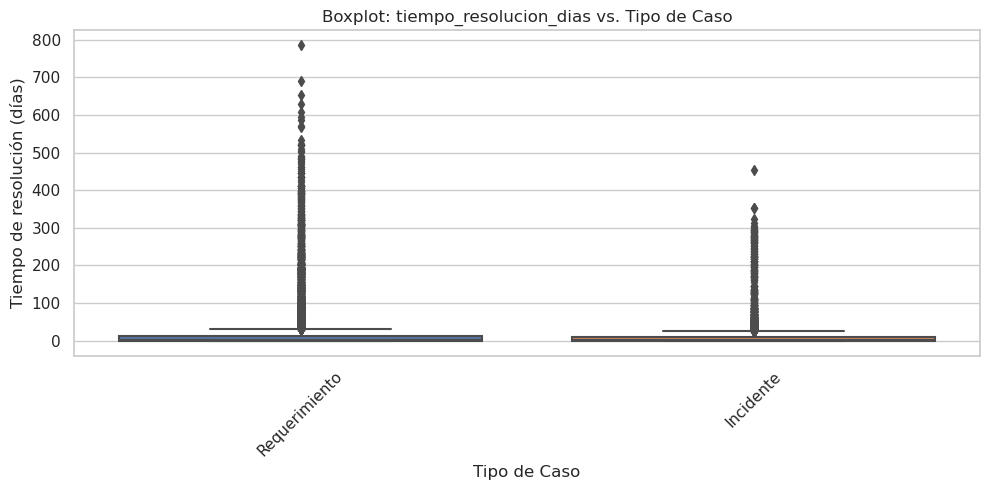

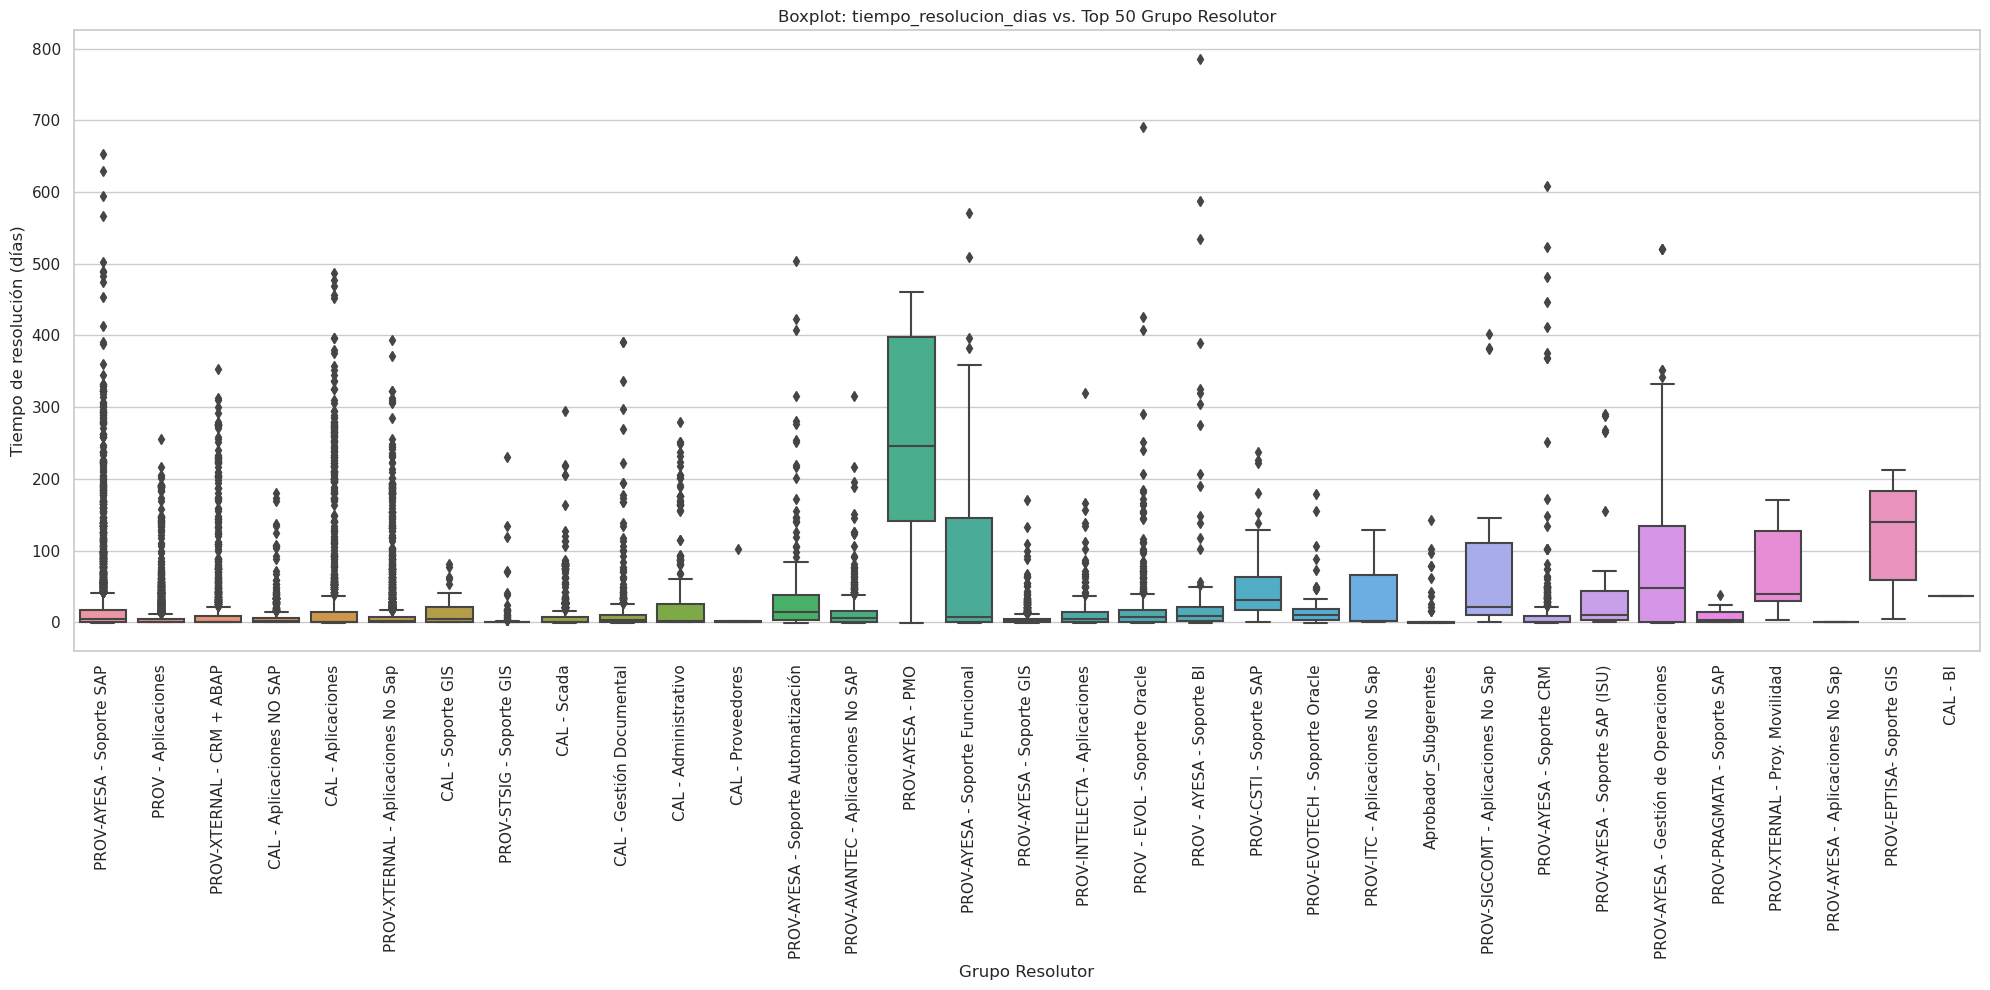

In [22]:
# ─────────────────────────────────────────────────────────────
# Paso 6.3: Boxplots de tiempo_resolucion_dias por categoría
# ─────────────────────────────────────────────────────────────

# Comprobar si las columnas existen
if 'tiempo_resolucion_dias' in df.columns:

    # Boxplot por Tipo de Caso
    if 'Tipo de Caso' in df.columns:
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=df, x='Tipo de Caso', y='tiempo_resolucion_dias')
        plt.title("Boxplot: tiempo_resolucion_dias vs. Tipo de Caso")
        plt.xlabel("Tipo de Caso")
        plt.ylabel("Tiempo de resolución (días)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # Boxplot por Grupo Resolutor
    if 'Grupo Resolutor' in df.columns:
        plt.figure(figsize=(20, 10))
        top_grupos = df['Grupo Resolutor'].value_counts().nlargest(50).index
        df_top = df[df['Grupo Resolutor'].isin(top_grupos)]

        sns.boxplot(data=df_top, x='Grupo Resolutor', y='tiempo_resolucion_dias')
        plt.title("Boxplot: tiempo_resolucion_dias vs. Top 50 Grupo Resolutor")
        plt.xlabel("Grupo Resolutor")
        plt.ylabel("Tiempo de resolución (días)")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
else:
    print("⚠️ La columna 'tiempo_resolucion_dias' no está disponible.")


In [23]:
# ─────────────────────────────────────────────────────────────
# Paso 6.4: Matriz de correlación entre variables numéricas
# ─────────────────────────────────────────────────────────────

# Filtrar columnas numéricas del DataFrame
numericas = df.select_dtypes(include=['int64', 'float64'])

# Calcular la matriz de correlación
matriz_corr = numericas.corr()

# Calcular la matriz de correlación
#matriz_corr = numericas.corr().round(2)

# Preparar datos para Plotly
z = matriz_corr.values
x = matriz_corr.columns.tolist()
y = matriz_corr.index.tolist()

# Texto para hover (información al pasar el ratón)
hover_text = [[f"Variable X: {x[j]}<br>Variable Y: {y[i]}<br>Correlación: {z[i][j]:.2f}" 
              for j in range(len(x))] for i in range(len(y))]

# Capa de calor base
heatmap = go.Heatmap(
    z=z,
    x=x,
    y=y,
    colorscale='Oranges',  # Escala de colores rojo-azul para correlaciones
    zmin=-1,  # Valor mínimo para correlación
    zmax=1,   # Valor máximo para correlación
    text=hover_text,
    hoverinfo="text",
    showscale=True
)

# Superponer texto con los valores de correlación
text_overlay = go.Scatter(
    x=np.repeat(x, len(y)),
    y=np.tile(y, len(x)),
    mode="text",
    text=[f"{val:.2f}" for row in z for val in row],
    textfont=dict(color="black", size=10),
    hoverinfo="skip"
)

# Construir figura final
fig = go.Figure(data=[heatmap, text_overlay])

fig.update_layout(
    title="🔍 Matriz de Correlación entre Variables Numéricas",
    xaxis=dict(
        title="Variables",
        tickangle=-45,
        side="top"
    ),
    yaxis=dict(
        title="Variables",
        autorange='reversed'  # Para que el orden sea igual que en seaborn
    ),
    width=1000,
    height=1000,
    margin=dict(l=150, r=50, b=150, t=300),
    hoverlabel=dict(
        bgcolor="white",
        font_size=12,
        font_family="Arial"
    )
)

fig.show()


StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 25, Finished, Available, Finished)

In [24]:
# ─────────────────────────────────────────────────────────────
# Separación de los 100 últimos casos completos por fechas
# ─────────────────────────────────────────────────────────────

# Asegurar formato datetime
fechas_clave = [
    'Fecha de Registro', 'Fecha Solución', 'Fecha Cierre',
    'Fecha último Estado', 'Fecha_Entrega_Esperada' 
]
for col in fechas_clave:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Filtrar registros con fechas completas
df_validos = df.dropna(subset=fechas_clave)

# Ordenar por Fecha de Registro (más recientes primero)
df_validos = df_validos.sort_values('Fecha de Registro', ascending=False)

# Seleccionar 100 casos recientes
df_nuevos = df_validos.head(100).copy()
casos_nuevos = df_nuevos['Caso'].tolist()

# Etiquetar como nuevos
df_nuevos["origen"] = "Nuevos"

# Crear dataset histórico (sin los 100)
df_historico = df[~df['Caso'].isin(casos_nuevos)].copy()
df_historico["origen"] = "Histórico"

# ─────────────────────────────────────────────────────────────
# Guardar ambos DataFrames como tablas en Silver con conteo
# ─────────────────────────────────────────────────────────────

# Función para mostrar conteo y guardar
def guardar_con_conteo(df_spark, nombre_tabla):
    # Mostrar conteo antes de guardar
    conteo = df_spark.count()
    print(f"📊 Registros a guardar en {nombre_tabla}: {conteo:,}")
    
    # Guardar tabla
    spark.sql(f"DROP TABLE IF EXISTS Silver.{nombre_tabla}")
    df_spark.write.mode("overwrite").saveAsTable(f"Silver.{nombre_tabla}")
    return conteo

# Reemplazar Inf y NaN por None
for dfx in [df_nuevos, df_historico]:
    dfx.replace([np.inf, -np.inf], np.nan, inplace=True)
    dfx = dfx.where(pd.notnull(dfx), None)

# → HISTÓRICO
df_spark_hist = spark.createDataFrame(df_historico)
df_spark_hist = df_spark_hist.toDF(*[col.replace(" ", "_") for col in df_spark_hist.columns])
conteo_historico = guardar_con_conteo(df_spark_hist, "BD_ARANDA_SILVER")

# → NUEVOS 100
df_spark_nuevos = spark.createDataFrame(df_nuevos)
df_spark_nuevos = df_spark_nuevos.toDF(*[col.replace(" ", "_") for col in df_spark_nuevos.columns])
conteo_nuevos = guardar_con_conteo(df_spark_nuevos, "BD_ARANDA_SILVER_100")

# Resumen final
print("\n✅ Tablas Silver actualizadas correctamente:")
print(f" - BD_ARANDA_SILVER (Histórico): {conteo_historico:,} registros")
print(f" - BD_ARANDA_SILVER_100 (Nuevos): {conteo_nuevos:,} registros")
print(f"📌 Total general procesado: {conteo_historico + conteo_nuevos:,} registros")





StatementMeta(, 3694ceb0-f720-46b3-be63-135385f992de, 26, Finished, Available, Finished)

/opt/spark/python/lib/pyspark.zip/pyspark/sql/pandas/conversion.py:351: UserWarning:

createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Expected bytes, got a 'int' object
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.



📊 Registros a guardar en BD_ARANDA_SILVER: 19,748
📊 Registros a guardar en BD_ARANDA_SILVER_100: 100

✅ Tablas Silver actualizadas correctamente:
 - BD_ARANDA_SILVER (Histórico): 19,748 registros
 - BD_ARANDA_SILVER_100 (Nuevos): 100 registros
📌 Total general procesado: 19,848 registros
